In [644]:
%load_ext autoreload
%autoreload 2

import importlib 
m = importlib.import_module(".model", "src")
em = importlib.import_module(".em", "src")
em_ = importlib.import_module(".em_new", "src")
sem = importlib.import_module(".sem", "src")
# ll  = importlib.import_module(".likelihoods", "src")

from matplotlib import pyplot as plt
import numpy as np
import xgi
import scipy.special as ss
import cProfile

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [812]:
# generate some sample data

eta   = 0.5   # node retention in edges
beta  = 1.4   # poisson number of novel nodes
gamma = 1.6   # poisson number of nodes from graph

timesteps = int(1e5)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)

In [813]:
len(H.degree_sequence())
H.edge_size_sequence().mean()

6.96765064698706

In [814]:
EM = sem.SEM(H, pars = {"eta"   : 0.3, 
                        "beta"  : 0.4, 
                        "gamma" : 0.02})

# l = []
# for i in range(1000):
#     S = EM.SE_step()
#     l.append(S[0])
# #     l.append((S[0] - 1) / (S[0] + S[1] - 1))
# # (S[0] - 1)/(S[0] + S[1] -1)
# np.mean(l)

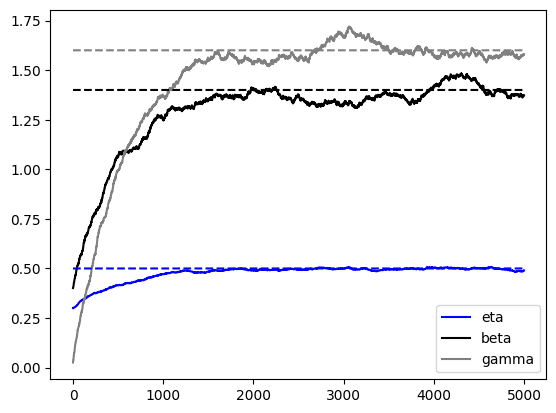

In [815]:
ETA   = []
BETA  = []
GAMMA = []
steps = 5000

for _ in range(steps):
    EM.SEM_step(0.002, min_time = 3*timesteps/4)
    ETA.append(EM.pars["eta"])
    BETA.append(EM.pars["beta"])
    GAMMA.append(EM.pars["gamma"])
    # print(EM.pars)
T = np.arange(steps)
plt.plot(T, ETA,   label = "eta", color = "blue")
plt.plot(T, BETA,  label = "beta", color = "black")
plt.plot(T, GAMMA, label = "gamma", color = "grey")

plt.plot(T, np.ones((steps,))*eta, color = "blue", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*beta, color = "black", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*gamma, color = "grey", linestyle = "dashed")
plt.legend()